# Intervalle de confiance en Python

## Exemple pratique avec le dataset `tips` de Seaborn

> Objectif : comprendre la notion d’intervalle de confiance à partir d’un exemple concret : les additions et les pourboires dans un restaurant.

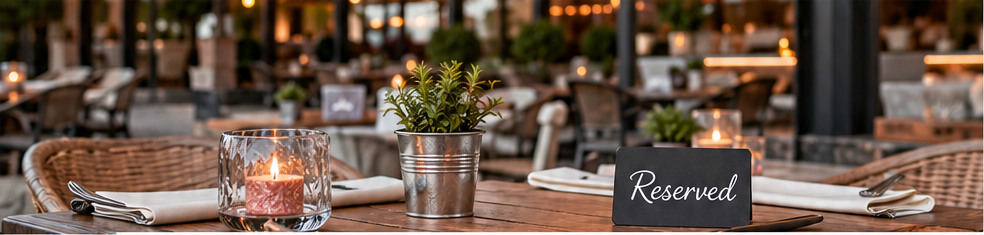

Dans la vie quotidienne, nous travaillons souvent avec des échantillons.  
Un restaurant peut, par exemple, vouloir estimer le montant moyen des additions ou des pourboires à partir d’un nombre limité de repas observés.

L’intervalle de confiance permet d’ajouter une information essentielle :  
il ne donne pas seulement une moyenne, il indique aussi l’incertitude autour de cette moyenne.

## 1. Pourquoi parler d’intervalle de confiance ?

Lorsque l’on calcule une moyenne à partir d’un échantillon, cette moyenne n’est généralement pas exactement égale à la vraie moyenne de toute la population.

Par exemple, si l’on observe seulement quelques additions dans un restaurant, la moyenne obtenue dépend des clients présents ce jour-là.  
Un autre jour, avec d’autres clients, la moyenne pourrait être légèrement différente.

L’intervalle de confiance répond donc à une question simple :

> À partir de l’échantillon observé, dans quelle zone plausible pourrait se trouver la vraie moyenne ?

In [3]:
# =====================================================================
# 2. Chargement des bibliothèques
# =====================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Style visuel proche des exemples classiques Seaborn
sns.set_theme(style="whitegrid", context="talk", palette="deep")

# Reproductibilité des simulations
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("Bibliothèques chargées.")
print(f"Seaborn : {sns.__version__}")
print(f"Pandas  : {pd.__version__}")

Bibliothèques chargées.
Seaborn : 0.12.2
Pandas  : 3.0.3


## 3. Chargement du dataset `tips`

Le dataset `tips` est un jeu de données intégré à Seaborn.  
Il contient des informations sur des repas dans un restaurant, notamment :

- le montant total de l’addition ;
- le montant du pourboire ;
- le sexe du client ;
- le jour ;
- le moment du repas ;
- la taille du groupe à table.

Ce dataset est pratique pour expliquer les intervalles de confiance, car il contient des variables numériques et des catégories faciles à comprendre.

In [4]:
# =====================================================================
# 3. Chargement du dataset
# =====================================================================

def create_fallback_tips_dataset(n: int = 244) -> pd.DataFrame:
    '''
    Crée un petit dataset synthétique inspiré du dataset tips.
    Cette solution de repli permet d'exécuter le notebook même si
    sns.load_dataset("tips") n'est pas accessible.
    '''
    days = rng.choice(["Thur", "Fri", "Sat", "Sun"], size=n, p=[0.25, 0.15, 0.35, 0.25])
    time = np.where(np.isin(days, ["Sat", "Sun"]), "Dinner", rng.choice(["Lunch", "Dinner"], size=n))
    size = rng.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.55, 0.18, 0.14, 0.05, 0.03])
    sex = rng.choice(["Male", "Female"], size=n, p=[0.62, 0.38])
    smoker = rng.choice(["Yes", "No"], size=n, p=[0.38, 0.62])

    base = rng.normal(17, 6, size=n)
    weekend_effect = np.where(np.isin(days, ["Sat", "Sun"]), 4, 0)
    size_effect = size * rng.normal(2.2, 0.5, size=n)
    total_bill = np.clip(base + weekend_effect + size_effect, 5, 55).round(2)

    tip_rate = rng.normal(0.15, 0.035, size=n)
    tip = np.clip(total_bill * tip_rate + rng.normal(0, 0.5, size=n), 0.5, 10).round(2)

    return pd.DataFrame({
        "total_bill": total_bill,
        "tip": tip,
        "sex": sex,
        "smoker": smoker,
        "day": days,
        "time": time,
        "size": size
    })

try:
    tips = sns.load_dataset("tips")
    print("Dataset tips chargé avec sns.load_dataset('tips').")
except Exception as exc:
    print("Le dataset Seaborn n'a pas pu être chargé. Utilisation d'un dataset synthétique de repli.")
    print(f"Détail technique : {exc}")
    tips = create_fallback_tips_dataset()

tips.head()

Dataset tips chargé avec sns.load_dataset('tips').


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
# =====================================================================
# 4. Aperçu et statistiques descriptives
# =====================================================================

print(f"Nombre de lignes : {len(tips)}")
print(f"Nombre de colonnes : {tips.shape[1]}")

tips[["total_bill", "tip", "size"]].describe().round(2)

Nombre de lignes : 244
Nombre de colonnes : 7


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


## 4. Première intuition : une moyenne n’est pas une certitude

Le montant moyen d’une addition est une estimation.

Si l’on observe 244 repas, on peut calculer une moyenne.  
Mais cette moyenne dépend de l’échantillon observé.

L’intervalle de confiance ajoute une information importante : il indique une plage de valeurs plausibles pour la vraie moyenne.

In [6]:
# =====================================================================
# 5. Calcul manuel d'un intervalle de confiance pour une moyenne
# =====================================================================

def mean_confidence_interval(values, confidence=0.95):
    '''
    Calcule l'intervalle de confiance d'une moyenne avec la loi de Student.
    '''
    values = pd.Series(values).dropna().astype(float)
    n = len(values)
    mean = values.mean()
    std = values.std(ddof=1)
    standard_error = std / np.sqrt(n)

    alpha = 1 - confidence
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin_error = t_critical * standard_error

    return {
        "n": n,
        "moyenne": mean,
        "ecart_type": std,
        "erreur_standard": standard_error,
        "marge_erreur": margin_error,
        "borne_inferieure": mean - margin_error,
        "borne_superieure": mean + margin_error
    }

ci_total_bill = mean_confidence_interval(tips["total_bill"], confidence=0.95)
ci_tip = mean_confidence_interval(tips["tip"], confidence=0.95)

pd.DataFrame([ci_total_bill, ci_tip], index=["Addition totale", "Pourboire"]).round(3)

,n,moyenne,ecart_type,erreur_standard,marge_erreur,borne_inferieure,borne_superieure
Addition totale,244,19.79,8.90,0.57,1.12,18.66,20.91
Pourboire,244,3.00,1.38,0.09,0.17,2.82,3.17


### Interprétation

L’intervalle de confiance à 95 % indique une zone plausible pour la vraie moyenne.

Par exemple, si la moyenne observée de l’addition est autour de 20 dollars et que l’intervalle est `[18,8 ; 21,0]`, cela signifie que les données disponibles suggèrent que la vraie moyenne pourrait raisonnablement se situer dans cette plage.

Il ne faut pas interpréter cela comme :  
“95 % des additions sont dans cet intervalle”.

La bonne idée est plutôt :  
“à partir de cet échantillon, cette plage est plausible pour la moyenne réelle”.

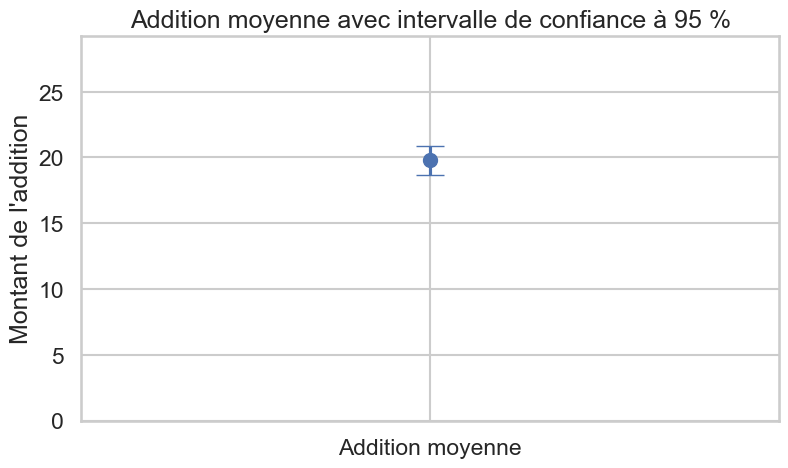

Moyenne observée : 19.79
Intervalle de confiance à 95 % : [18.66, 20.91]


In [7]:
# =====================================================================
# 6. Visualisation d'une moyenne avec son intervalle de confiance
# =====================================================================

mean_bill = ci_total_bill["moyenne"]
low_bill = ci_total_bill["borne_inferieure"]
high_bill = ci_total_bill["borne_superieure"]

plt.figure(figsize=(9, 5))
plt.errorbar(
    x=["Addition moyenne"],
    y=[mean_bill],
    yerr=[[mean_bill - low_bill], [high_bill - mean_bill]],
    fmt="o",
    capsize=10,
    markersize=10
)
plt.title("Addition moyenne avec intervalle de confiance à 95 %")
plt.ylabel("Montant de l'addition")
plt.ylim(0, max(high_bill * 1.4, 10))
plt.show()

print(f"Moyenne observée : {mean_bill:.2f}")
print(f"Intervalle de confiance à 95 % : [{low_bill:.2f}, {high_bill:.2f}]")

## 5. Graphique classique : moyenne par jour avec intervalle de confiance

Le graphique suivant est l’un des plus courants pour visualiser un intervalle de confiance.

Chaque barre représente la moyenne des additions pour un jour donné.  
La petite barre verticale au-dessus de chaque colonne représente l’intervalle de confiance autour de cette moyenne.

Plus cette barre verticale est grande, plus l’estimation est incertaine.

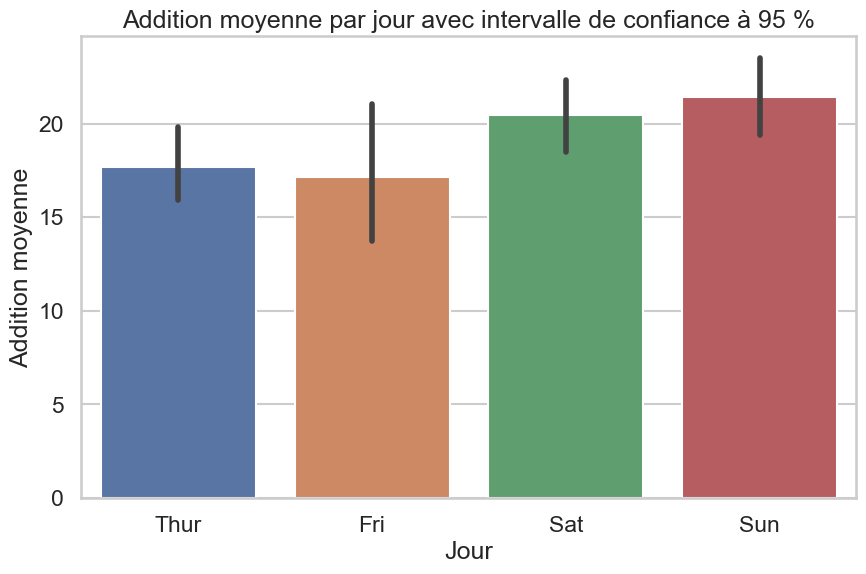

In [8]:
# =====================================================================
# 7. Barplot Seaborn avec intervalle de confiance
# =====================================================================

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tips,
    x="day",
    y="total_bill",
    errorbar=("ci", 95),
    order=["Thur", "Fri", "Sat", "Sun"]
)
plt.title("Addition moyenne par jour avec intervalle de confiance à 95 %")
plt.xlabel("Jour")
plt.ylabel("Addition moyenne")
plt.show()

### Interprétation du graphique

Ce graphique ne montre pas seulement la moyenne par jour.  
Il montre aussi l’incertitude autour de cette moyenne.

Deux jours peuvent avoir des moyennes différentes, mais si leurs intervalles de confiance se chevauchent fortement, il faut rester prudent avant de conclure que la différence est réellement importante.

L’intervalle de confiance aide donc à éviter des conclusions trop rapides à partir d’un simple graphique de moyennes.

## 6. Comparer deux dimensions : jour et moment du repas

On peut aussi visualiser l’incertitude en comparant plusieurs groupes.

Ici, on compare l’addition moyenne selon :

- le jour ;
- le moment du repas : déjeuner ou dîner.

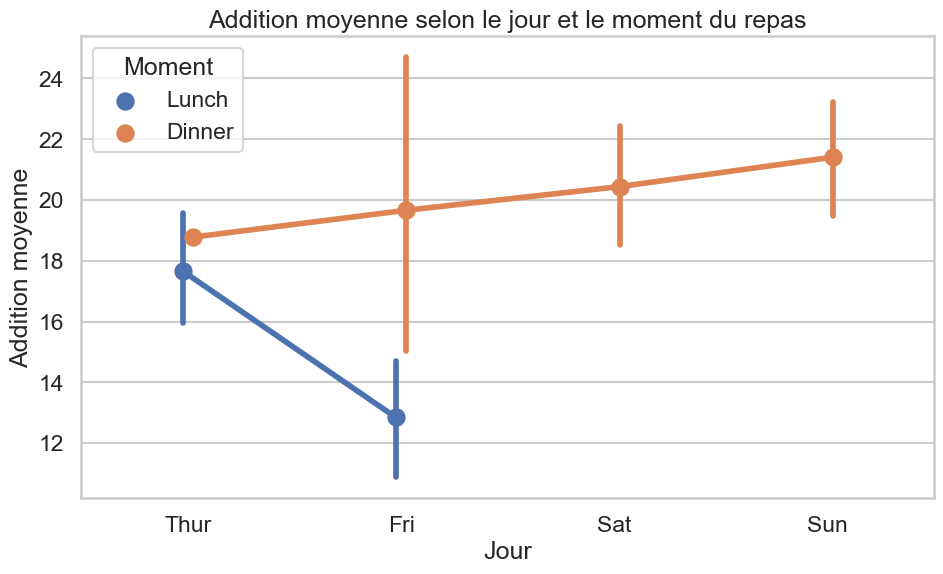

In [9]:
# =====================================================================
# 8. Pointplot avec intervalle de confiance
# =====================================================================

plt.figure(figsize=(11, 6))
sns.pointplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="time",
    errorbar=("ci", 95),
    order=["Thur", "Fri", "Sat", "Sun"],
    dodge=True,
    markers="o",
    linestyles="-"
)
plt.title("Addition moyenne selon le jour et le moment du repas")
plt.xlabel("Jour")
plt.ylabel("Addition moyenne")
plt.legend(title="Moment")
plt.show()

### À retenir

Le `pointplot` est utile pour comparer plusieurs catégories.

Les points représentent les moyennes.  
Les segments verticaux représentent les intervalles de confiance.

Ce type de graphique permet de voir rapidement si certaines catégories semblent associées à des montants plus élevés, tout en gardant une indication visuelle de l’incertitude.

## 7. Relation entre deux variables : addition et pourboire

Les intervalles de confiance peuvent aussi apparaître autour d’une tendance.

Dans le graphique suivant :

- chaque point représente un repas ;
- la ligne représente la tendance moyenne entre l’addition et le pourboire ;
- la bande autour de la ligne représente l’intervalle de confiance de cette tendance.

C’est le type de graphique que l’on voit souvent avec une régression linéaire simple.

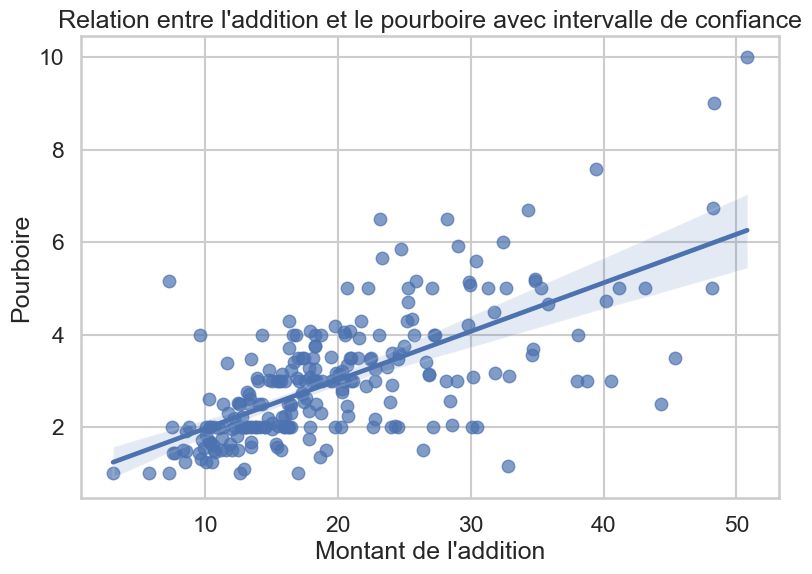

In [10]:
# =====================================================================
# 9. Regplot : relation entre l'addition et le pourboire
# =====================================================================

plt.figure(figsize=(9, 6))
sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    ci=95,
    scatter_kws={"alpha": 0.7}
)
plt.title("Relation entre l'addition et le pourboire avec intervalle de confiance")
plt.xlabel("Montant de l'addition")
plt.ylabel("Pourboire")
plt.show()

### Interprétation

La ligne indique la tendance générale : plus l’addition est élevée, plus le pourboire tend à être élevé.

La bande claire autour de la ligne représente l’incertitude autour de cette tendance.  
Elle est souvent plus étroite là où les données sont nombreuses, et plus large là où il y a moins d’observations.

Ce graphique montre que l’intervalle de confiance n’est pas seulement utile pour une moyenne : il peut aussi aider à visualiser l’incertitude autour d’une relation entre deux variables.

## 8. Graphique en ligne avec bande d’intervalle de confiance

Un autre graphique classique consiste à représenter une moyenne selon une variable ordonnée.

Ici, on observe le pourboire moyen selon la taille du groupe à table.

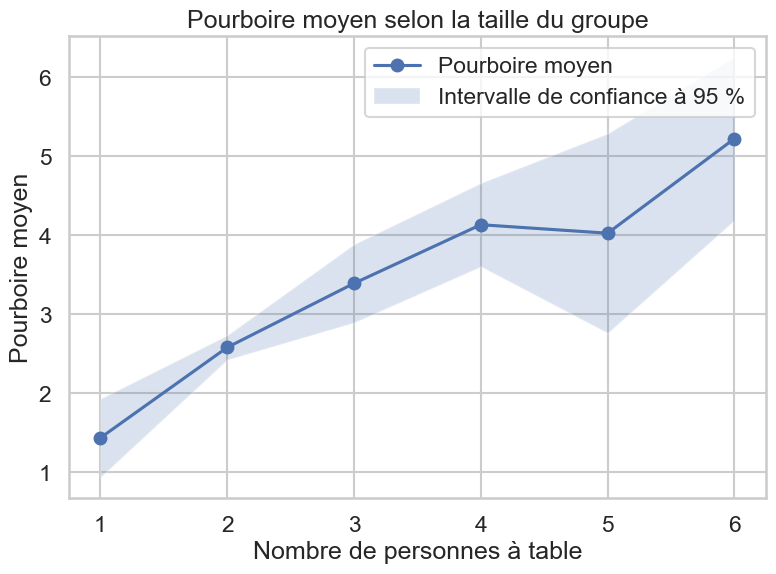

In [12]:
# =====================================================================
# 10. Lineplot manuel avec intervalle de confiance
# =====================================================================

summary = (
    tips
    .groupby("size")["tip"]
    .agg(["mean", "count", "std"])
    .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]
summary["low"] = summary["mean"] - summary["ci95"]
summary["high"] = summary["mean"] + summary["ci95"]

plt.figure(figsize=(9, 6))

plt.plot(
    summary["size"],
    summary["mean"],
    marker="o",
    label="Pourboire moyen"
)

plt.fill_between(
    summary["size"],
    summary["low"],
    summary["high"],
    alpha=0.2,
    label="Intervalle de confiance à 95 %"
)

plt.title("Pourboire moyen selon la taille du groupe")
plt.xlabel("Nombre de personnes à table")
plt.ylabel("Pourboire moyen")
plt.legend()
plt.show()

### Interprétation

La ligne montre comment le pourboire moyen évolue selon la taille du groupe.  
La bande autour de la ligne représente l’intervalle de confiance à 95 %.

Lorsque la bande est large, cela signifie que l’estimation est moins précise.  
Cela peut arriver lorsqu’il y a peu d’observations pour certaines tailles de groupe.

## 9. Effet de la taille de l’échantillon

Un principe important :

> Plus l’échantillon est grand, plus l’intervalle de confiance tend à devenir étroit.

Cela ne signifie pas que les données deviennent parfaites, mais que l’estimation de la moyenne devient généralement plus précise.

In [13]:
# =====================================================================
# 11. Effet de la taille de l'échantillon
# =====================================================================

sample_sizes = [10, 20, 50, 100, 200]
results = []

for n in sample_sizes:
    sample = tips["total_bill"].sample(n=min(n, len(tips)), random_state=RANDOM_STATE)
    ci = mean_confidence_interval(sample, confidence=0.95)
    results.append({
        "taille_echantillon": ci["n"],
        "moyenne": ci["moyenne"],
        "borne_inferieure": ci["borne_inferieure"],
        "borne_superieure": ci["borne_superieure"],
        "marge_erreur": ci["marge_erreur"]
    })

sample_effect = pd.DataFrame(results)
sample_effect.round(3)

,taille_echantillon,moyenne,borne_inferieure,borne_superieure,marge_erreur
0,10,18.10,13.48,22.72,4.62
1,20,18.09,14.51,21.67,3.58
2,50,17.97,15.35,20.60,2.62
3,100,19.27,17.56,20.98,1.71
4,200,19.53,18.29,20.77,1.24


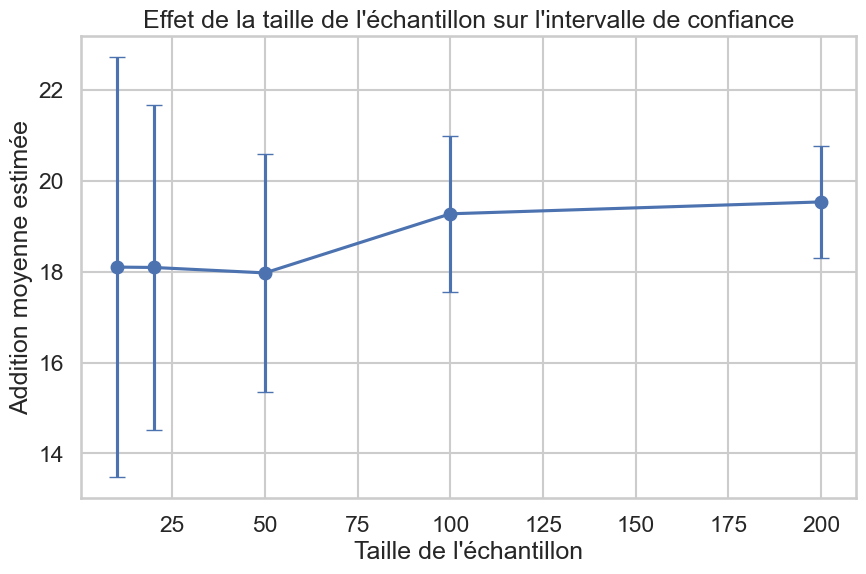

In [14]:
plt.figure(figsize=(10, 6))
plt.errorbar(
    sample_effect["taille_echantillon"],
    sample_effect["moyenne"],
    yerr=[
        sample_effect["moyenne"] - sample_effect["borne_inferieure"],
        sample_effect["borne_superieure"] - sample_effect["moyenne"]
    ],
    fmt="o-",
    capsize=6
)
plt.title("Effet de la taille de l'échantillon sur l'intervalle de confiance")
plt.xlabel("Taille de l'échantillon")
plt.ylabel("Addition moyenne estimée")
plt.show()

### Interprétation

Lorsque la taille de l’échantillon augmente, l’intervalle de confiance tend à devenir plus court.

Cela illustre une idée fondamentale en statistique :  
une estimation fondée sur davantage d’observations est généralement plus stable qu’une estimation fondée sur très peu d’observations.

## 10. Intervalle de confiance pour une proportion

Les intervalles de confiance ne concernent pas seulement les moyennes.  
Ils peuvent aussi être utilisés pour les proportions.

Exemple : quelle proportion de repas correspond au dîner (`Dinner`) dans le dataset ?

In [15]:
# =====================================================================
# 12. Intervalle de confiance pour une proportion
# =====================================================================

is_dinner = (tips["time"] == "Dinner").astype(int)
n = len(is_dinner)
p_hat = is_dinner.mean()

# Approximation normale pour une proportion
z = stats.norm.ppf(0.975)
standard_error_prop = np.sqrt(p_hat * (1 - p_hat) / n)
margin_error_prop = z * standard_error_prop

prop_low = p_hat - margin_error_prop
prop_high = p_hat + margin_error_prop

print(f"Proportion observée de repas Dinner : {p_hat:.2%}")
print(f"Intervalle de confiance à 95 % : [{prop_low:.2%}, {prop_high:.2%}]")

Proportion observée de repas Dinner : 72.13%
Intervalle de confiance à 95 % : [66.51%, 77.76%]


### Interprétation

La proportion observée est calculée à partir de l’échantillon.

L’intervalle de confiance indique une zone plausible pour la proportion réelle, si l’on considérait une population plus large de repas similaires.

## 11. Méthode bootstrap

Le bootstrap est une méthode très intuitive.

L’idée est de recréer plusieurs échantillons à partir des données observées, en tirant les lignes avec remise.  
Pour chaque nouvel échantillon, on recalcule la moyenne.

À la fin, on obtient une distribution de moyennes possibles.

In [16]:
# =====================================================================
# 13. Bootstrap de la moyenne des additions
# =====================================================================

bootstrap_iterations = 10_000
bootstrap_means = []

values = tips["total_bill"].dropna().to_numpy()

for _ in range(bootstrap_iterations):
    sample = rng.choice(values, size=len(values), replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

boot_low, boot_high = np.percentile(bootstrap_means, [2.5, 97.5])
boot_mean = bootstrap_means.mean()

print(f"Moyenne observée : {values.mean():.2f}")
print(f"Intervalle bootstrap à 95 % : [{boot_low:.2f}, {boot_high:.2f}]")

Moyenne observée : 19.79
Intervalle bootstrap à 95 % : [18.69, 20.91]


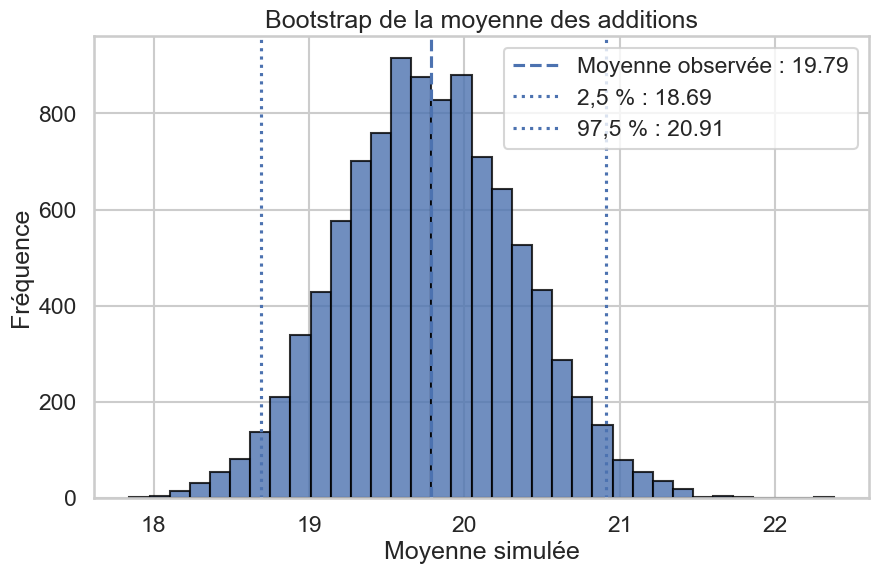

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=35, edgecolor="black", alpha=0.8)
plt.axvline(values.mean(), linestyle="--", label=f"Moyenne observée : {values.mean():.2f}")
plt.axvline(boot_low, linestyle=":", label=f"2,5 % : {boot_low:.2f}")
plt.axvline(boot_high, linestyle=":", label=f"97,5 % : {boot_high:.2f}")
plt.title("Bootstrap de la moyenne des additions")
plt.xlabel("Moyenne simulée")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

### Interprétation du bootstrap

Le graphique montre la distribution des moyennes obtenues par bootstrap.

La ligne centrale représente la moyenne observée dans les données.  
Les lignes pointillées indiquent les limites de l’intervalle bootstrap à 95 %.

Cette méthode est particulièrement utile lorsqu’on veut comprendre l’incertitude d’une estimation sans s’appuyer uniquement sur une formule théorique.

## 12. Erreurs fréquentes d’interprétation

Voici quelques erreurs courantes à éviter :

1. Dire que 95 % des valeurs individuelles sont dans l’intervalle.  
   Ce n’est pas le cas. L’intervalle concerne l’estimation de la moyenne, pas toutes les observations.

2. Dire que la vraie moyenne a exactement 95 % de probabilité d’être dans cet intervalle.  
   En statistique classique, la vraie moyenne est considérée comme fixe. C’est la méthode d’échantillonnage qui produit des intervalles variables.

3. Conclure trop vite qu’un groupe est différent d’un autre.  
   Il faut regarder les intervalles, la taille de l’échantillon et le contexte.

4. Oublier que l’intervalle dépend de la qualité des données.  
   Un intervalle bien calculé ne corrige pas un mauvais échantillon.

## Conclusion

Ce notebook a montré comment comprendre et visualiser les intervalles de confiance avec Python.

À retenir :

- une moyenne observée est une estimation ;
- l’intervalle de confiance exprime l’incertitude autour de cette estimation ;
- les graphiques avec barres d’erreur ou bandes de confiance aident à mieux interpréter les résultats ;
- la taille de l’échantillon influence la précision ;
- le bootstrap permet de visualiser l’incertitude de façon intuitive.

Les intervalles de confiance sont donc essentiels pour éviter de présenter une estimation comme une certitude.

In [18]:
# =====================================================================
# 14. Fonction réutilisable
# =====================================================================

def afficher_intervalle_confiance_moyenne(data, column, confidence=0.95):
    '''
    Fonction réutilisable pour calculer et afficher l'intervalle de confiance
    d'une moyenne.
    '''
    ci = mean_confidence_interval(data[column], confidence=confidence)

    print(f"Variable : {column}")
    print(f"Nombre d'observations : {ci['n']}")
    print(f"Moyenne observée : {ci['moyenne']:.2f}")
    print(f"Intervalle de confiance à {confidence:.0%} : "
          f"[{ci['borne_inferieure']:.2f}, {ci['borne_superieure']:.2f}]")

    return ci

afficher_intervalle_confiance_moyenne(tips, "tip")

Variable : tip
Nombre d'observations : 244
Moyenne observée : 3.00
Intervalle de confiance à 95% : [2.82, 3.17]


{'n': 244,
 'moyenne': 2.99827868852459,
 'ecart_type': 1.3836381890011822,
 'erreur_standard': 0.088578358337857,
 'marge_erreur': 0.17447938224284607,
 'borne_inferieure': 2.8237993062817437,
 'borne_superieure': 3.172758070767436}

### Interprétation du résultat

Dans cette dernière étape, nous avons créé une fonction réutilisable pour calculer automatiquement l’intervalle de confiance d’une moyenne.

La fonction `afficher_intervalle_confiance_moyenne()` reçoit trois informations :

- le jeu de données utilisé ;
- la colonne numérique à analyser ;
- le niveau de confiance souhaité, ici 95 % par défaut.

Dans cet exemple, la fonction est appliquée à la variable `tip`, qui correspond au montant du pourboire.

Le résultat indique que le dataset contient 244 observations. La moyenne observée des pourboires est d’environ 3,00 dollars.

Cependant, cette moyenne est calculée à partir d’un échantillon. Elle ne doit donc pas être interprétée comme une valeur parfaitement exacte pour tous les repas possibles dans un restaurant similaire.

L’intervalle de confiance à 95 % obtenu est :

`[2.82, 3.17]`

Cela signifie que, selon les données disponibles, la vraie moyenne des pourboires se situe probablement entre 2,82 et 3,17 dollars.

La fonction retourne aussi plusieurs valeurs utiles :

- `n` : le nombre d’observations utilisées ;
- `moyenne` : la moyenne observée dans l’échantillon ;
- `ecart_type` : la dispersion des valeurs autour de la moyenne ;
- `erreur_standard` : l’incertitude associée à l’estimation de la moyenne ;
- `marge_erreur` : la distance ajoutée et retirée autour de la moyenne ;
- `borne_inferieure` et `borne_superieure` : les limites de l’intervalle de confiance.

L’intérêt de cette fonction est de rendre le calcul réutilisable. Elle peut être appliquée à d’autres colonnes numériques du dataset, par exemple `total_bill`, afin d’obtenir rapidement une estimation accompagnée de son niveau d’incertitude.

Cette étape résume l’idée centrale du notebook : en science des données, il est souvent insuffisant de présenter une moyenne seule. Il est préférable d’accompagner cette moyenne d’un intervalle de confiance, car cela permet de mieux comprendre la précision et les limites de l’estimation.